In [1]:
from os import makedirs

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import Margins

OUTPUT_DIR = '03_output'
makedirs(OUTPUT_DIR, exist_ok=True)

df_enroll = pd.read_csv('data/enrollments.csv', low_memory=False)

# limit to years after 1990
m = df_enroll['year'] >= 1990
df_enroll = df_enroll[m]

df_gdp = pd.read_csv('data/Countries GDP 1960-2020.csv')

In [2]:
# wrangle GDP data to format to merge with enrollment data.
# Transpose and stack columns. Some noise that disappears after merge.

df_gdp.set_index('Country Code', inplace=True)
df_gdp = df_gdp.T

X = []
for col in df_gdp.columns:
    sub_df = df_gdp[col].copy().reset_index()
    sub_df['Country Code'] = col
    sub_df.rename(columns={col: 'GDP'}, inplace=True)
    X.append(sub_df)

df_gdp = pd.concat(X)

In [3]:
df_gdp.rename(columns={'Country Code': 'countrycode', 'index': 'year'}, inplace=True)
df_gdp['year'] = pd.to_numeric(df_gdp['year'], errors='coerce')
df_gdp['GDP'] = pd.to_numeric(df_gdp['GDP'], errors='coerce')

In [4]:
# Working with log of GDP is more intuitive.
# it has a wide range of values without,
# and I assume there is a diminishing returns effect where more is needed for less

df_gdp['GDP'] = np.floor(np.log10(df_gdp['GDP']))

In [5]:
df = df_enroll.merge(df_gdp, on=['countrycode', 'year'])

In [6]:
df = df[['countrycode', 'year', 'GDP', 'students5_estimated', 'iau_id1']]
df['year'] -= 1990
df['year'] /= 5

In [7]:
# Drop rows with NaNs in key columns to prevent model fit errors
df = df.dropna(subset=['students5_estimated', 'year', 'GDP', 'countrycode'])

# Count data lends itself well to Poisson regression
# Data is clustered (university), and has a time variable, so GEE is appropriate
fam = sm.families.Poisson()
ind = sm.cov_struct.Exchangeable()

f = "students5_estimated ~ year*C(GDP, Treatment(reference=8.0))"
mod = smf.gee(f, "iau_id1", df,
               time=df['year'], cov_struct=ind, family=fam)

fit = mod.fit(maxiter=500)
print(fit.summary())

# positive effect with larger GDP.
# There is also a temporal effect where the universities in countries with lower GDP are "catching up."
# Obviously, this is a quick analysis but passes the sniff test.
# Money buys access, but access to information has gotten cheaper,
# and there has been increased demand for white collar jobs

                               GEE Regression Results                              
Dep. Variable:         students5_estimated   No. Observations:                59857
Model:                                 GEE   No. clusters:                    10177
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   7
Family:                            Poisson   Mean cluster size:                 5.9
Dependence structure:         Exchangeable   Num. iterations:                   228
Date:                     Sun, 14 Jun 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         15:30:54
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept       

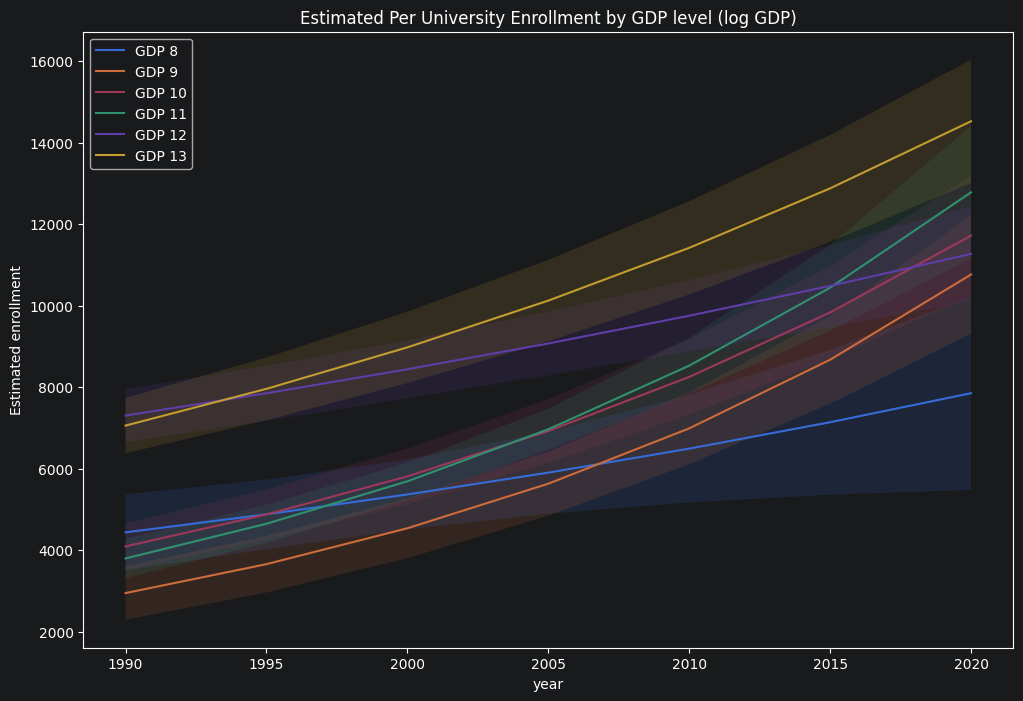

In [8]:
# Estimate GDP Marginal effect on enrollment by year accross all log GDP levels.

m = Margins.linear_scale(fit, at="overall")
res = m.predict(atexog={"GDP": [8,9,10,11,12,13], 'year':[0,1,2,3,4,5,6]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(12, 8))
for level, sub_df in df_plot.groupby("GDP"):
    label = f"GDP {level}"
    ax.plot(sub_df["year"], sub_df["estimate"], label=label)
    ax.fill_between(
        sub_df["year"], sub_df["ci_lower"], sub_df["ci_upper"], alpha=0.15
    )
ax.set(xlabel="year", ylabel="Estimated enrollment")
ax.set_xticks(range(0, 7))
ax.set_xticklabels([1990 + 5*i for i in range(0, 7)])
ax.set_title("Estimated Per University Enrollment by GDP level (log GDP)")
ax.legend()
plt.savefig(f'{OUTPUT_DIR}/gdp_enrollment_effects.png')
plt.show()

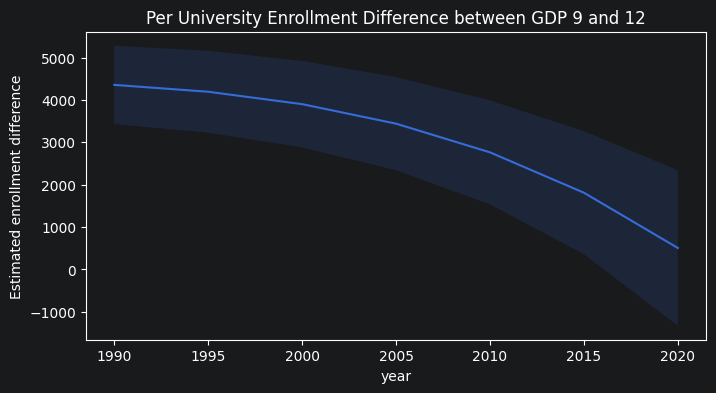

In [9]:
# Estimate GDP Marginal effect contrast (difference) on enrollment by year.
# Selected level 9 and 12.
# Difference of the two curves in the previous plot.
# This shows the "catch up" effect.

scen = []

for i in range(0, 7):
    scen.append({'atexog': {'GDP': 12, 'year':i}, 'label': 'wot=1'})
    scen.append({'atexog': {'GDP': 9, 'year':i}, 'label': 'wot=0'})

w = []

for i in range(0, 7):
    x = 14 * [0]
    x[i * 2] = 1
    x[i * 2 + 1] = -1
    w.append(x)

res = m.contrasts(scenarios=scen, contrasts=w)

df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_plot.index, df_plot["estimate"])
ax.fill_between(
    df_plot.index, df_plot["ci_lower"], df_plot["ci_upper"], alpha=0.15
)
ax.set(xlabel="year", ylabel="Estimated enrollment difference")
ax.set_xticks(range(0, 7))
ax.set_xticklabels([1990 + 5*i for i in range(0, 7)])
ax.set_title("Per University Enrollment Difference between GDP 9 and 12")
plt.savefig(f'{OUTPUT_DIR}/gdp_enrollment_contrast.png')
plt.show()